# Malware Classification using Machine Learning Models
### Original vs SMOTE vs Borderline-SMOTE vs ADASYN vs CTGAN vs TVAE vs cGAN
## Model Evaluation & Hyperparameter Tuning

---
## 1. Project Overview

**Objective:** Classify malware memory-forensics samples (CIC-MalMem-2022) and compare the effect of different data-augmentation / synthetic-data-generation techniques (SMOTE, Borderline-SMOTE, ADASYN, CTGAN, TVAE, custom PyTorch cGAN) on classifier performance.

**Dataset Description:** CIC-MalMem-2022 memory forensics dataset. 7 versions are used here: the original dataset plus 6 augmented/synthetic variants.

**Classification Problem:** Multi-class malware family / benign-vs-malicious classification based on memory-forensics extracted features.

**Models Used:** Random Forest, XGBoost, LightGBM, SVM.

**Evaluation Metrics:** Accuracy, Precision, Recall, Macro/Weighted P-R-F1, MCC, ROC-AUC, PR-AUC, Cohen's Kappa, Balanced Accuracy, Log Loss.

> **Note:** The original outline lists 6 dataset variants (Original/SMOTE/Borderline-SMOTE/ADASYN/CTGAN/TVAE). Since 7 files are available (including a custom PyTorch `cGAN_balanced` dataset), an extra dataset group has been added throughout so **every file is covered** without skipping any section from the requested list.

---
## 2. Import Required Libraries

In [1]:
# ============================================================
# Imports
# ============================================================
import os
import time
import json
import warnings
import joblib

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# ============================================================
# Scikit-Learn
# ============================================================
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    RandomizedSearchCV,
)

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    label_binarize,
)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    average_precision_score,
    cohen_kappa_score,
    balanced_accuracy_score,
    log_loss,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

# ============================================================
# XGBoost
# ============================================================
try:
    import xgboost as xgb
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False
    print("XGBoost not installed.")

# ============================================================
# LightGBM
# ============================================================
try:
    import lightgbm as lgb
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False
    print("LightGBM not installed.")

# ============================================================
# Statistical Tests
# ============================================================
from scipy.stats import wilcoxon, friedmanchisquare

try:
    import scikit_posthocs as sp
    HAS_POSTHOC = True
except ImportError:
    HAS_POSTHOC = False

# ============================================================
# SHAP
# ============================================================
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

# ============================================================
# Random Seed
# ============================================================
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ============================================================
# Dataset Location
# ============================================================
DATA_DIR = "/kaggle/input/datasets/shanmukhadattaboda/malmem-augmneted-5-class-datasets"

if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(f"Dataset directory not found:\n{DATA_DIR}")

# ============================================================
# Dataset Files
# ============================================================
DATASETS = {
    "Original": "MalMem2022.csv",
    "SMOTE": "MalMem2022_SMOTE.csv",
    "Borderline-SMOTE": "MalMem2022_BorderlineSMOTE.csv",
    "ADASYN": "MalMem2022_ADASYN.csv",
    "CTGAN": "MalMem2022_CTGAN_balanced.csv",
    "TVAE": "MalMem2022_TVAE_balanced.csv",
    "cGAN": "MalMem2022_cGAN_balanced.csv",
}

# Check dataset files
print("=" * 60)
print("Dataset Availability")
print("=" * 60)

for name, file in DATASETS.items():
    path = os.path.join(DATA_DIR, file)

    if os.path.exists(path):
        print(f"✓ {name:20} {file}")
    else:
        print(f"✗ {name:20} NOT FOUND -> {file}")

# ============================================================
# Output Directories
# ============================================================
OUTPUT_DIR = "outputs"

FIGURE_DIR = os.path.join(OUTPUT_DIR, "figures")
MODEL_DIR = os.path.join(OUTPUT_DIR, "models")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# ============================================================
# Environment Information
# ============================================================
print("\nEnvironment Ready")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"XGBoost      : {HAS_XGBOOST}")
print(f"LightGBM     : {HAS_LIGHTGBM}")
print(f"SHAP         : {HAS_SHAP}")
print(f"PostHoc Test : {HAS_POSTHOC}")

Dataset Availability
✓ Original             MalMem2022.csv
✓ SMOTE                MalMem2022_SMOTE.csv
✓ Borderline-SMOTE     MalMem2022_BorderlineSMOTE.csv
✓ ADASYN               MalMem2022_ADASYN.csv
✓ CTGAN                MalMem2022_CTGAN_balanced.csv
✓ TVAE                 MalMem2022_TVAE_balanced.csv
✓ cGAN                 MalMem2022_cGAN_balanced.csv

Environment Ready
NumPy        : 2.0.2
Pandas       : 2.3.3
XGBoost      : True
LightGBM     : True
SHAP         : True
PostHoc Test : False


---
## 3-8. Load Datasets (Original, SMOTE, Borderline-SMOTE, ADASYN, CTGAN, TVAE, cGAN)

In [2]:
raw = {}
for name, fname in DATASETS.items():
    path = os.path.join(DATA_DIR, fname)
    print(f'Loading {name}: {path}')
    raw[name] = pd.read_csv(path)
print('\nAll datasets loaded:', list(raw.keys()))

Loading Original: /kaggle/input/datasets/shanmukhadattaboda/malmem-augmneted-5-class-datasets/MalMem2022.csv


Loading SMOTE: /kaggle/input/datasets/shanmukhadattaboda/malmem-augmneted-5-class-datasets/MalMem2022_SMOTE.csv


Loading Borderline-SMOTE: /kaggle/input/datasets/shanmukhadattaboda/malmem-augmneted-5-class-datasets/MalMem2022_BorderlineSMOTE.csv


Loading ADASYN: /kaggle/input/datasets/shanmukhadattaboda/malmem-augmneted-5-class-datasets/MalMem2022_ADASYN.csv


Loading CTGAN: /kaggle/input/datasets/shanmukhadattaboda/malmem-augmneted-5-class-datasets/MalMem2022_CTGAN_balanced.csv


Loading TVAE: /kaggle/input/datasets/shanmukhadattaboda/malmem-augmneted-5-class-datasets/MalMem2022_TVAE_balanced.csv


Loading cGAN: /kaggle/input/datasets/shanmukhadattaboda/malmem-augmneted-5-class-datasets/MalMem2022_cGAN_balanced.csv



All datasets loaded: ['Original', 'SMOTE', 'Borderline-SMOTE', 'ADASYN', 'CTGAN', 'TVAE', 'cGAN']


---
## 9. Verify Dataset Shapes

In [3]:
for name, df in raw.items():
    print(f'{name:20s} shape = {df.shape}')

Original             shape = (58596, 56)
SMOTE                shape = (117192, 56)
Borderline-SMOTE     shape = (117192, 56)
ADASYN               shape = (117707, 56)
CTGAN                shape = (116924, 56)
TVAE                 shape = (116924, 56)
cGAN                 shape = (116924, 56)


## 10. Verify Number of Features

In [4]:
for name, df in raw.items():
    n_feats = df.shape[1] - 1  # assuming last column is target
    print(f'{name:20s} -> {n_feats} features')

Original             -> 55 features
SMOTE                -> 55 features
Borderline-SMOTE     -> 55 features
ADASYN               -> 55 features
CTGAN                -> 55 features
TVAE                 -> 55 features
cGAN                 -> 55 features


## 11. Verify Target Labels

In [5]:
TARGET_COL = raw['Original'].columns[-1]  # adjust if your target column has a different name/position
print('Target column:', TARGET_COL)
for name, df in raw.items():
    print(f'{name:20s} classes -> {sorted(df[TARGET_COL].unique().tolist())}')

Target column: Label
Original             classes -> ['Benign', 'Ransomware', 'Spyware', 'Trojan']
SMOTE                classes -> ['Benign', 'Ransomware', 'Spyware', 'Trojan']
Borderline-SMOTE     classes -> ['Benign', 'Ransomware', 'Spyware', 'Trojan']
ADASYN               classes -> ['Benign', 'Ransomware', 'Spyware', 'Trojan']
CTGAN                classes -> ['Benign', 'Ransomware', 'Spyware', 'Trojan']
TVAE                 classes -> ['Benign', 'Ransomware', 'Spyware', 'Trojan']
cGAN                 classes -> ['Benign', 'Ransomware', 'Spyware', 'Trojan']


## 12. Check Missing Values

In [6]:
for name, df in raw.items():
    n_missing = df.isnull().sum().sum()
    print(f'{name:20s} missing values = {n_missing}')

Original             missing values = 0


SMOTE                missing values = 0
Borderline-SMOTE     missing values = 0
ADASYN               missing values = 0
CTGAN                missing values = 0
TVAE                 missing values = 0
cGAN                 missing values = 0


## 13. Check Duplicate Values

In [7]:
for name, df in raw.items():
    n_dupes = df.duplicated().sum()
    print(f'{name:20s} duplicate rows = {n_dupes}')

Original             duplicate rows = 559
SMOTE                duplicate rows = 1113


Borderline-SMOTE     duplicate rows = 964
ADASYN               duplicate rows = 912


CTGAN                duplicate rows = 25
TVAE                 duplicate rows = 25


cGAN                 duplicate rows = 25


## 14. Check Data Types

In [8]:
for name, df in raw.items():
    print(f'--- {name} dtypes ---')
    print(df.dtypes.value_counts())
    print()

--- Original dtypes ---
int64      40
float64    15
object      1
Name: count, dtype: int64

--- SMOTE dtypes ---
int64      40
float64    15
object      1
Name: count, dtype: int64

--- Borderline-SMOTE dtypes ---
int64      40
float64    15
object      1
Name: count, dtype: int64

--- ADASYN dtypes ---
int64      40
float64    15
object      1
Name: count, dtype: int64

--- CTGAN dtypes ---
int64      40
float64    15
object      1
Name: count, dtype: int64

--- TVAE dtypes ---
int64      40
float64    15
object      1
Name: count, dtype: int64

--- cGAN dtypes ---
float64    44
int64      11
object      1
Name: count, dtype: int64



## 15. Compare Class Distributions

In [9]:
for name, df in raw.items():
    print("="*60)
    print(name)
    print(df.columns.tolist())

Original
['pslist.nproc', 'pslist.nppid', 'pslist.avg_threads', 'pslist.nprocs64bit', 'pslist.avg_handlers', 'dlllist.ndlls', 'dlllist.avg_dlls_per_proc', 'handles.nhandles', 'handles.avg_handles_per_proc', 'handles.nport', 'handles.nfile', 'handles.nevent', 'handles.ndesktop', 'handles.nkey', 'handles.nthread', 'handles.ndirectory', 'handles.nsemaphore', 'handles.ntimer', 'handles.nsection', 'handles.nmutant', 'ldrmodules.not_in_load', 'ldrmodules.not_in_init', 'ldrmodules.not_in_mem', 'ldrmodules.not_in_load_avg', 'ldrmodules.not_in_init_avg', 'ldrmodules.not_in_mem_avg', 'malfind.ninjections', 'malfind.commitCharge', 'malfind.protection', 'malfind.uniqueInjections', 'psxview.not_in_pslist', 'psxview.not_in_eprocess_pool', 'psxview.not_in_ethread_pool', 'psxview.not_in_pspcid_list', 'psxview.not_in_csrss_handles', 'psxview.not_in_session', 'psxview.not_in_deskthrd', 'psxview.not_in_pslist_false_avg', 'psxview.not_in_eprocess_pool_false_avg', 'psxview.not_in_ethread_pool_false_avg', '

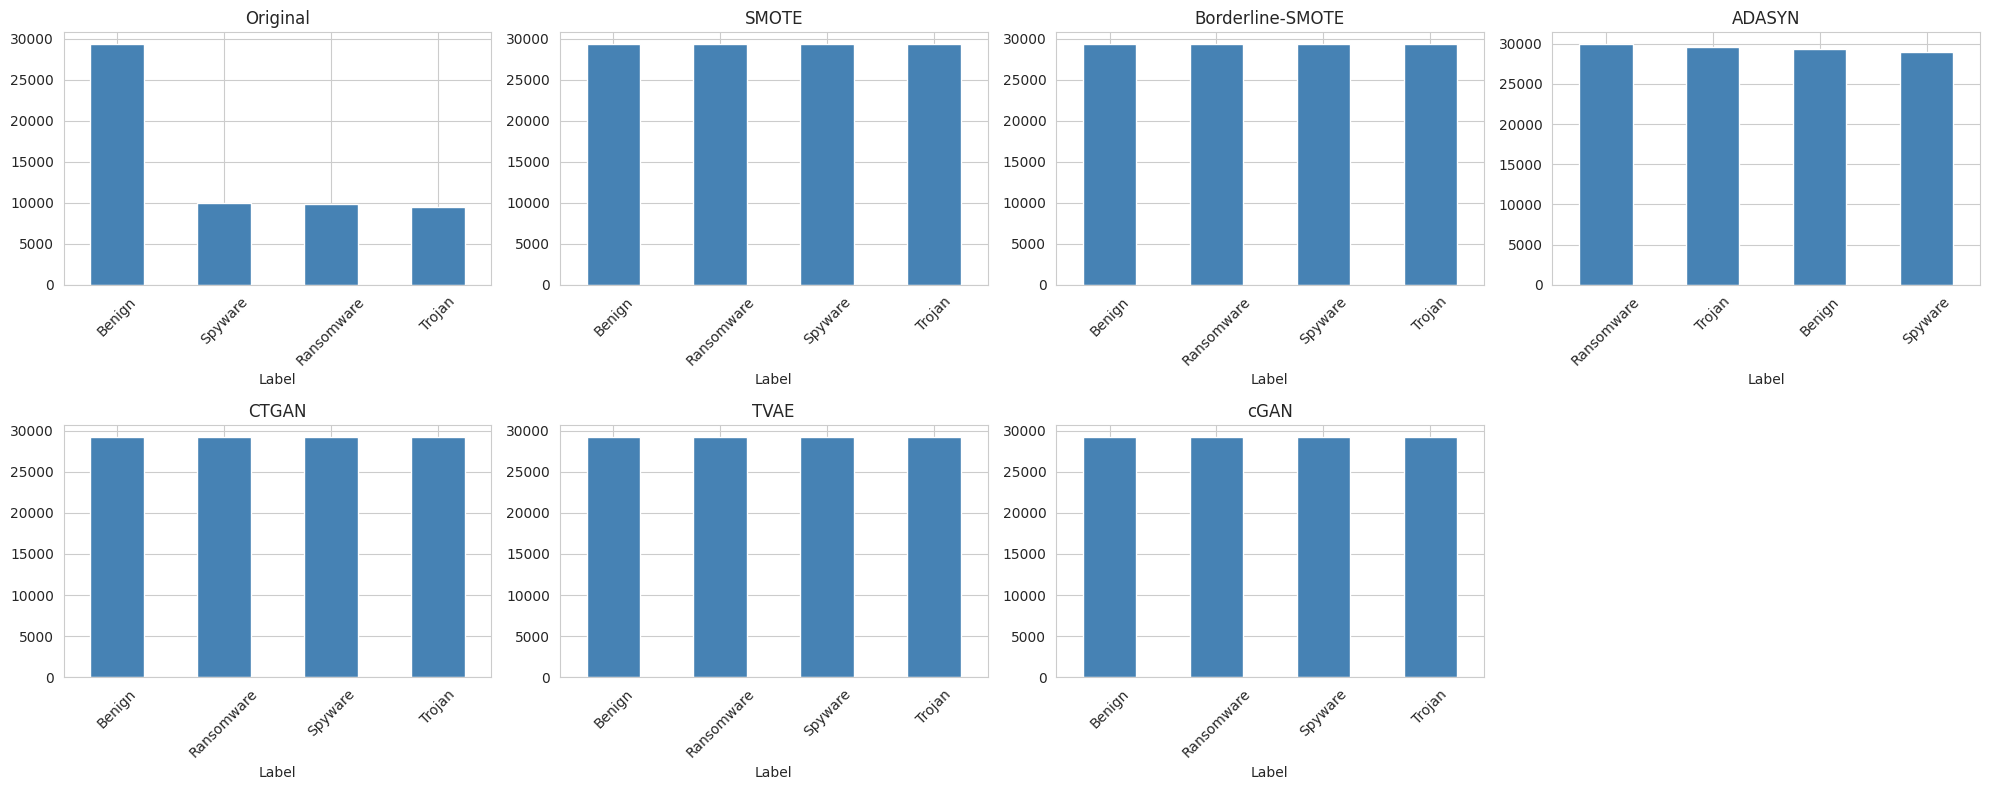

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.flatten()
for i, (name, df) in enumerate(raw.items()):
    df[TARGET_COL].value_counts().plot(kind='bar', ax=axes[i], color='steelblue')
    axes[i].set_title(name)
    axes[i].tick_params(axis='x', rotation=45)
for j in range(len(raw), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.savefig('outputs/figures/class_distributions.png', dpi=150)
plt.show()

---
## 16. Separate Features and Target

In [11]:
X_dict, y_dict = {}, {}
for name, df in raw.items():
    X_dict[name] = df.drop(columns=[TARGET_COL])
    y_dict[name] = df[TARGET_COL]

## 17. Label Encoding (if required)

In [12]:
le = LabelEncoder()
le.fit(y_dict['Original'])
y_enc = {name: le.transform(y) for name, y in y_dict.items()}
print('Encoded classes:', dict(zip(le.classes_, le.transform(le.classes_))))

Encoded classes: {'Benign': np.int64(0), 'Ransomware': np.int64(1), 'Spyware': np.int64(2), 'Trojan': np.int64(3)}


## 18. Feature Scaling (SVM only)

In [13]:
scalers = {}
X_scaled = {}
for name, X in X_dict.items():
    scaler = StandardScaler()
    X_scaled[name] = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)
    scalers[name] = scaler

## 19. Train-Test Split

In [14]:
splits = {}          # unscaled splits (RF / XGBoost / LightGBM)
splits_scaled = {}    # scaled splits (SVM)
for name in DATASETS:
    X_train, X_test, y_train, y_test = train_test_split(
        X_dict[name], y_enc[name], test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc[name])
    splits[name] = (X_train, X_test, y_train, y_test)

    Xs_train, Xs_test, ys_train, ys_test = train_test_split(
        X_scaled[name], y_enc[name], test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc[name])
    splits_scaled[name] = (Xs_train, Xs_test, ys_train, ys_test)
print('Splits created for:', list(splits.keys()))

Splits created for: ['Original', 'SMOTE', 'Borderline-SMOTE', 'ADASYN', 'CTGAN', 'TVAE', 'cGAN']


## 20. Verify Class Distribution (after split)

In [15]:
for name, (X_train, X_test, y_train, y_test) in splits.items():
    print(f'{name:20s} train dist: {np.bincount(y_train)}  test dist: {np.bincount(y_test)}')

Original             train dist: [23438  7833  8016  7589]  test dist: [5860 1958 2004 1898]
SMOTE                train dist: [23438 23439 23438 23438]  test dist: [5860 5859 5860 5860]
Borderline-SMOTE     train dist: [23438 23439 23438 23438]  test dist: [5860 5859 5860 5860]
ADASYN               train dist: [23438 23929 23120 23678]  test dist: [5860 5983 5780 5919]
CTGAN                train dist: [23385 23385 23384 23385]  test dist: [5846 5846 5847 5846]
TVAE                 train dist: [23385 23385 23384 23385]  test dist: [5846 5846 5847 5846]
cGAN                 train dist: [23385 23385 23384 23385]  test dist: [5846 5846 5847 5846]


---
## 21-24. Baseline Models (Default Hyperparameters, on Original Dataset)

In [16]:
X_train, X_test, y_train, y_test = splits['Original']
Xs_train, Xs_test, ys_train, ys_test = splits_scaled['Original']

baseline_models = {
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE),
    'XGBoost': xgb.XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE),
    'LightGBM': lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
    'SVM': SVC(probability=True, random_state=RANDOM_STATE),
}

baseline_scores = {}
for mname, model in baseline_models.items():
    Xtr, Xte = (Xs_train, Xs_test) if mname == 'SVM' else (X_train, X_test)
    model.fit(Xtr, y_train)
    acc = accuracy_score(y_test, model.predict(Xte))
    baseline_scores[mname] = acc
    print(f'{mname:15s} baseline accuracy (default params) = {acc:.4f}')

Random Forest   baseline accuracy (default params) = 0.8735


XGBoost         baseline accuracy (default params) = 0.8722


LightGBM        baseline accuracy (default params) = 0.8691


SVM             baseline accuracy (default params) = 0.7646


---
## 25-26. Random Forest Hyperparameter Tuning & Best Model

In [17]:
rf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
}
rf_search = RandomizedSearchCV(RandomForestClassifier(random_state=RANDOM_STATE), rf_param_grid,
                                n_iter=20, cv=3, scoring='f1_macro', n_jobs=-1, random_state=RANDOM_STATE)
rf_search.fit(X_train, y_train)
best_rf = rf_search.best_estimator_
print('Best RF params:', rf_search.best_params_)

Best RF params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}


## 27-28. XGBoost Hyperparameter Tuning & Best Model

In [18]:
xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}
xgb_search = RandomizedSearchCV(xgb.XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE),
                                 xgb_param_grid, n_iter=20, cv=3, scoring='f1_macro', n_jobs=-1,
                                 random_state=RANDOM_STATE)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_
print('Best XGBoost params:', xgb_search.best_params_)

Best XGBoost params: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 9, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


## 29-30. LightGBM Hyperparameter Tuning & Best Model

In [19]:
lgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [-1, 5, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'num_leaves': [15, 31, 63, 127],
    'subsample': [0.7, 0.8, 1.0],
}
lgb_search = RandomizedSearchCV(lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1),
                                 lgb_param_grid, n_iter=20, cv=3, scoring='f1_macro', n_jobs=-1,
                                 random_state=RANDOM_STATE)
lgb_search.fit(X_train, y_train)
best_lgb = lgb_search.best_estimator_
print('Best LightGBM params:', lgb_search.best_params_)

Best LightGBM params: {'subsample': 1.0, 'num_leaves': 127, 'n_estimators': 200, 'max_depth': -1, 'learning_rate': 0.05}


## 31-32. SVM Hyperparameter Tuning & Best Model

In [20]:
svm_param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['rbf', 'linear', 'poly'],
    'gamma': ['scale', 'auto'],
}
svm_search = RandomizedSearchCV(SVC(probability=True, random_state=RANDOM_STATE), svm_param_grid,
                                 n_iter=12, cv=3, scoring='f1_macro', n_jobs=-1, random_state=RANDOM_STATE)
svm_search.fit(Xs_train, ys_train)
best_svm = svm_search.best_estimator_
print('Best SVM params:', svm_search.best_params_)

# Tuning is performed once on the Original dataset and the resulting hyperparameters are reused
# consistently across all dataset variants below, so that comparisons isolate the effect of the
# augmentation technique rather than re-introducing tuning variance for every dataset.
BEST_PARAMS = {
    'Random Forest': rf_search.best_params_,
    'XGBoost': xgb_search.best_params_,
    'LightGBM': lgb_search.best_params_,
    'SVM': svm_search.best_params_,
}

Best SVM params: {'kernel': 'rbf', 'gamma': 'scale', 'C': 100}


---
## 33-35. Stratified K-Fold Cross Validation, Mean CV Score, Std Dev

In [21]:
def make_model(mname, params):
    if mname == 'Random Forest':
        return RandomForestClassifier(random_state=RANDOM_STATE, **params)
    if mname == 'XGBoost':
        return xgb.XGBClassifier(eval_metric='mlogloss', random_state=RANDOM_STATE, **params)
    if mname == 'LightGBM':
        return lgb.LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, **params)
    if mname == 'SVM':
        return SVC(probability=True, random_state=RANDOM_STATE, **params)
    raise ValueError(mname)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = {}  # cv_scores[(dataset, model)] = array of fold scores

for dname in DATASETS:
    Xtr_full, _, ytr_full, _ = splits[dname]
    Xtr_full_s, _, ytr_full_s, _ = splits_scaled[dname]
    for mname in BEST_PARAMS:
        Xcv, ycv = (Xtr_full_s, ytr_full_s) if mname == 'SVM' else (Xtr_full, ytr_full)
        model = make_model(mname, BEST_PARAMS[mname])
        scores = cross_val_score(model, Xcv, ycv, cv=skf, scoring='f1_macro', n_jobs=-1)
        cv_scores[(dname, mname)] = scores
        print(f'{dname:18s} | {mname:15s} mean CV Macro-F1 = {scores.mean():.4f}  std = {scores.std():.4f}')

Original           | Random Forest   mean CV Macro-F1 = 0.8101  std = 0.0023


Original           | XGBoost         mean CV Macro-F1 = 0.8206  std = 0.0032


Original           | LightGBM        mean CV Macro-F1 = 0.8244  std = 0.0011


Original           | SVM             mean CV Macro-F1 = 0.6932  std = 0.0030


SMOTE              | Random Forest   mean CV Macro-F1 = 0.9123  std = 0.0011


...

ADASYN             | LightGBM        mean CV Macro-F1 = 0.8635  std = 0.0023


ADASYN             | SVM             mean CV Macro-F1 = 0.6818  std = 0.0025


CTGAN              | Random Forest   mean CV Macro-F1 = 0.6213  std = 0.0025


CTGAN              | XGBoost         mean CV Macro-F1 = 0.6161  std = 0.0032


CTGAN              | LightGBM        mean CV Macro-F1 = 0.6196  std = 0.0028


---
## 36-50. Evaluation Metrics
A single comprehensive metrics function is defined here (Accuracy, Precision, Recall, Macro/Weighted P-R-F1, MCC, ROC-AUC, PR-AUC, Cohen's Kappa, Balanced Accuracy, Log Loss). It is reused for every model/dataset combination trained further below, and each metric is inspected individually per the outline sections 36-50.

In [ ]:
def evaluate_all_metrics(y_true, y_pred, y_proba):
    metrics = {}
    metrics['accuracy'] = accuracy_score(y_true, y_pred)                                   # 36
    metrics['precision'] = precision_score(y_true, y_pred, average='micro', zero_division=0)  # 37
    metrics['recall'] = recall_score(y_true, y_pred, average='micro', zero_division=0)         # 38
    metrics['macro_precision'] = precision_score(y_true, y_pred, average='macro', zero_division=0)  # 39
    metrics['macro_recall'] = recall_score(y_true, y_pred, average='macro', zero_division=0)         # 40
    metrics['macro_f1'] = f1_score(y_true, y_pred, average='macro', zero_division=0)                 # 41
    metrics['weighted_precision'] = precision_score(y_true, y_pred, average='weighted', zero_division=0)  # 42
    metrics['weighted_recall'] = recall_score(y_true, y_pred, average='weighted', zero_division=0)        # 43
    metrics['weighted_f1'] = f1_score(y_true, y_pred, average='weighted', zero_division=0)                # 44
    metrics['mcc'] = matthews_corrcoef(y_true, y_pred)                                       # 45
    try:
        metrics['roc_auc'] = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')  # 46
    except Exception:
        metrics['roc_auc'] = np.nan
    try:
        y_bin = label_binarize(y_true, classes=np.unique(y_true))
        metrics['pr_auc'] = average_precision_score(y_bin, y_proba, average='macro')       # 47
    except Exception:
        metrics['pr_auc'] = np.nan
    metrics['cohen_kappa'] = cohen_kappa_score(y_true, y_pred)                              # 48
    metrics['balanced_accuracy'] = balanced_accuracy_score(y_true, y_pred)                  # 49
    try:
        metrics['log_loss'] = log_loss(y_true, y_proba)                                     # 50
    except Exception:
        metrics['log_loss'] = np.nan
    return metrics

### 37. Precision (micro)
This metric is computed inside `evaluate_all_metrics()` above and stored per model/dataset in `results_df` (built in section 64-87 below); see the comparison tables in sections 88-96.

### 38. Recall (micro)
This metric is computed inside `evaluate_all_metrics()` above and stored per model/dataset in `results_df` (built in section 64-87 below); see the comparison tables in sections 88-96.

### 39. Macro Precision
This metric is computed inside `evaluate_all_metrics()` above and stored per model/dataset in `results_df` (built in section 64-87 below); see the comparison tables in sections 88-96.

### 40. Macro Recall
This metric is computed inside `evaluate_all_metrics()` above and stored per model/dataset in `results_df` (built in section 64-87 below); see the comparison tables in sections 88-96.

### 41. Macro F1
This metric is computed inside `evaluate_all_metrics()` above and stored per model/dataset in `results_df` (built in section 64-87 below); see the comparison tables in sections 88-96.

### 42. Weighted Precision
This metric is computed inside `evaluate_all_metrics()` above and stored per model/dataset in `results_df` (built in section 64-87 below); see the comparison tables in sections 88-96.

### 43. Weighted Recall
This metric is computed inside `evaluate_all_metrics()` above and stored per model/dataset in `results_df` (built in section 64-87 below); see the comparison tables in sections 88-96.

### 44. Weighted F1
This metric is computed inside `evaluate_all_metrics()` above and stored per model/dataset in `results_df` (built in section 64-87 below); see the comparison tables in sections 88-96.

### 45. Matthews Correlation Coefficient (MCC)
This metric is computed inside `evaluate_all_metrics()` above and stored per model/dataset in `results_df` (built in section 64-87 below); see the comparison tables in sections 88-96.

### 46. ROC-AUC
This metric is computed inside `evaluate_all_metrics()` above and stored per model/dataset in `results_df` (built in section 64-87 below); see the comparison tables in sections 88-96.

### 47. PR-AUC
This metric is computed inside `evaluate_all_metrics()` above and stored per model/dataset in `results_df` (built in section 64-87 below); see the comparison tables in sections 88-96.

### 48. Cohen's Kappa
This metric is computed inside `evaluate_all_metrics()` above and stored per model/dataset in `results_df` (built in section 64-87 below); see the comparison tables in sections 88-96.

### 49. Balanced Accuracy
This metric is computed inside `evaluate_all_metrics()` above and stored per model/dataset in `results_df` (built in section 64-87 below); see the comparison tables in sections 88-96.

### 50. Log Loss
This metric is computed inside `evaluate_all_metrics()` above and stored per model/dataset in `results_df` (built in section 64-87 below); see the comparison tables in sections 88-96.

---
### Storage structures for trained models / predictions (used throughout the rest of the notebook)

In [ ]:
trained_models = {}     # trained_models[(dataset, model)] = fitted estimator
predictions = {}        # predictions[(dataset, model)] = (y_test, y_pred, y_proba)
results_rows = []       # list of dict rows -> results_df
feature_importances = {}
train_times = {}
predict_times = {}

---
## 51-54. Confusion Matrix helper (Random Forest / XGBoost / LightGBM / SVM)

In [ ]:
def plot_confusion(y_true, y_pred, title, save_path):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.close()

---
## 55-57. ROC Curve, Multi-class ROC Curve, ROC Comparison (helper)

In [ ]:
def plot_roc(y_true, y_proba, classes, title, save_path):
    y_bin = label_binarize(y_true, classes=classes)
    plt.figure(figsize=(7, 6))
    for i, cls in enumerate(classes):
        fpr, tpr, _ = roc_curve(y_bin[:, i], y_proba[:, i])
        auc_i = roc_auc_score(y_bin[:, i], y_proba[:, i])
        plt.plot(fpr, tpr, label=f'class {cls} (AUC={auc_i:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
    plt.title(title); plt.legend(fontsize=8)
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.close()

---
## 58-59. Precision-Recall Curve, PR Curve Comparison (helper)

In [ ]:
def plot_pr_curve(y_true, y_proba, classes, title, save_path):
    y_bin = label_binarize(y_true, classes=classes)
    plt.figure(figsize=(7, 6))
    for i, cls in enumerate(classes):
        prec, rec, _ = precision_recall_curve(y_bin[:, i], y_proba[:, i])
        ap = average_precision_score(y_bin[:, i], y_proba[:, i])
        plt.plot(rec, prec, label=f'class {cls} (AP={ap:.3f})')
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title(title); plt.legend(fontsize=8)
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.close()

---
## 60-63. Feature Importance helpers (Random Forest / XGBoost / LightGBM / SHAP optional)

In [ ]:
def plot_feature_importance(model, feature_names, title, save_path, top_n=20):
    if not hasattr(model, 'feature_importances_'):
        return None
    importances = model.feature_importances_
    idx = np.argsort(importances)[::-1][:top_n]
    plt.figure(figsize=(8, 6))
    sns.barplot(x=importances[idx], y=np.array(feature_names)[idx], color='teal')
    plt.title(title); plt.xlabel('Importance')
    plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.close()
    return dict(zip(np.array(feature_names)[idx], importances[idx]))

def shap_summary(model, X_sample, title, save_path):
    if not HAS_SHAP:
        print('shap not installed, skipping SHAP importance (pip install shap)')
        return
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)
    shap.summary_plot(shap_values, X_sample, show=False)
    plt.title(title); plt.tight_layout(); plt.savefig(save_path, dpi=150); plt.close()

---
## 64-87. Model Performance on Each Dataset (Original / SMOTE / Borderline-SMOTE / ADASYN / CTGAN / TVAE / cGAN)
For every dataset variant, all four tuned models (Random Forest, XGBoost, LightGBM, SVM) are trained and evaluated using the metrics function defined above. Results are appended to `results_rows`, and confusion matrices, ROC curves, PR curves, and feature importances are saved to `outputs/figures/`.

In [ ]:
def train_and_evaluate(dataset_name, model_name):
    X_train, X_test, y_train, y_test = splits[dataset_name]
    Xs_train, Xs_test, ys_train, ys_test = splits_scaled[dataset_name]
    use_scaled = model_name == 'SVM'
    Xtr, Xte = (Xs_train, Xs_test) if use_scaled else (X_train, X_test)
    ytr, yte = (ys_train, ys_test) if use_scaled else (y_train, y_test)

    model = make_model(model_name, BEST_PARAMS[model_name])
    t0 = time.time()
    model.fit(Xtr, ytr)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = model.predict(Xte)
    predict_time = time.time() - t0
    y_proba = model.predict_proba(Xte)

    metrics = evaluate_all_metrics(yte, y_pred, y_proba)
    metrics.update({'dataset': dataset_name, 'model': model_name,
                     'train_time_s': train_time, 'predict_time_s': predict_time})

    trained_models[(dataset_name, model_name)] = model
    predictions[(dataset_name, model_name)] = (yte, y_pred, y_proba)
    train_times[(dataset_name, model_name)] = train_time
    predict_times[(dataset_name, model_name)] = predict_time
    results_rows.append(metrics)

    tag = f'{dataset_name}_{model_name}'.replace(' ', '_')
    plot_confusion(yte, y_pred, f'Confusion Matrix: {model_name} on {dataset_name}',
                   f'outputs/figures/cm_{tag}.png')
    classes = np.unique(yte)
    plot_roc(yte, y_proba, classes, f'ROC: {model_name} on {dataset_name}',
             f'outputs/figures/roc_{tag}.png')
    plot_pr_curve(yte, y_proba, classes, f'PR Curve: {model_name} on {dataset_name}',
                  f'outputs/figures/pr_{tag}.png')
    fi = plot_feature_importance(model, X_train.columns, f'Feature Importance: {model_name} on {dataset_name}',
                                  f'outputs/figures/fi_{tag}.png')
    if fi is not None:
        feature_importances[(dataset_name, model_name)] = fi

    print(f'[{dataset_name:18s} | {model_name:15s}] acc={metrics["accuracy"]:.4f}  '
          f'macro_f1={metrics["macro_f1"]:.4f}  mcc={metrics["mcc"]:.4f}')
    return metrics

### Model Performance on Original Dataset

In [ ]:
train_and_evaluate('Original', 'Random Forest')

In [ ]:
train_and_evaluate('Original', 'XGBoost')

In [ ]:
train_and_evaluate('Original', 'LightGBM')

In [ ]:
train_and_evaluate('Original', 'SVM')

### Model Performance on SMOTE Dataset

In [ ]:
train_and_evaluate('SMOTE', 'Random Forest')

In [ ]:
train_and_evaluate('SMOTE', 'XGBoost')

In [ ]:
train_and_evaluate('SMOTE', 'LightGBM')

In [ ]:
train_and_evaluate('SMOTE', 'SVM')

### Model Performance on Borderline-SMOTE Dataset

In [ ]:
train_and_evaluate('Borderline-SMOTE', 'Random Forest')

In [ ]:
train_and_evaluate('Borderline-SMOTE', 'XGBoost')

In [ ]:
train_and_evaluate('Borderline-SMOTE', 'LightGBM')

In [ ]:
train_and_evaluate('Borderline-SMOTE', 'SVM')

### Model Performance on ADASYN Dataset

In [ ]:
train_and_evaluate('ADASYN', 'Random Forest')

In [ ]:
train_and_evaluate('ADASYN', 'XGBoost')

In [ ]:
train_and_evaluate('ADASYN', 'LightGBM')

In [ ]:
train_and_evaluate('ADASYN', 'SVM')

### Model Performance on CTGAN Dataset

In [ ]:
train_and_evaluate('CTGAN', 'Random Forest')

In [ ]:
train_and_evaluate('CTGAN', 'XGBoost')

In [ ]:
train_and_evaluate('CTGAN', 'LightGBM')

In [ ]:
train_and_evaluate('CTGAN', 'SVM')

### Model Performance on TVAE Dataset

In [ ]:
train_and_evaluate('TVAE', 'Random Forest')

In [ ]:
train_and_evaluate('TVAE', 'XGBoost')

In [ ]:
train_and_evaluate('TVAE', 'LightGBM')

In [ ]:
train_and_evaluate('TVAE', 'SVM')

### Model Performance on cGAN Dataset

In [ ]:
train_and_evaluate('cGAN', 'Random Forest')

In [ ]:
train_and_evaluate('cGAN', 'XGBoost')

In [ ]:
train_and_evaluate('cGAN', 'LightGBM')

In [ ]:
train_and_evaluate('cGAN', 'SVM')

In [ ]:
results_df = pd.DataFrame(results_rows)
results_df.to_csv('outputs/all_results.csv', index=False)
results_df.head(10)

---
## 88-96. Performance Comparison

### 88. Compare Accuracy

In [ ]:
pivot_accuracy = results_df.pivot(index='dataset', columns='model', values='accuracy')
display(pivot_accuracy)

### 89. Compare Macro F1

In [ ]:
pivot_macro_f1 = results_df.pivot(index='dataset', columns='model', values='macro_f1')
display(pivot_macro_f1)

### 90. Compare Weighted F1

In [ ]:
pivot_weighted_f1 = results_df.pivot(index='dataset', columns='model', values='weighted_f1')
display(pivot_weighted_f1)

### 91. Compare MCC

In [ ]:
pivot_mcc = results_df.pivot(index='dataset', columns='model', values='mcc')
display(pivot_mcc)

### 92. Compare ROC-AUC

In [ ]:
pivot_roc_auc = results_df.pivot(index='dataset', columns='model', values='roc_auc')
display(pivot_roc_auc)

### 93. Compare PR-AUC

In [ ]:
pivot_pr_auc = results_df.pivot(index='dataset', columns='model', values='pr_auc')
display(pivot_pr_auc)

### 94. Compare Training Time

In [ ]:
pivot_train_time_s = results_df.pivot(index='dataset', columns='model', values='train_time_s')
display(pivot_train_time_s)

### 95. Compare Prediction Time

In [ ]:
pivot_predict_time_s = results_df.pivot(index='dataset', columns='model', values='predict_time_s')
display(pivot_predict_time_s)

### 96. Compare Memory Usage

In [ ]:
import sys
mem_rows = []
for (dname, mname), model in trained_models.items():
    size_bytes = sys.getsizeof(joblib.dump(model, f'/tmp/_size_check.joblib'))
    size_mb = os.path.getsize('/tmp/_size_check.joblib') / (1024 ** 2)
    mem_rows.append({'dataset': dname, 'model': mname, 'model_size_mb': size_mb})
memory_df = pd.DataFrame(mem_rows)
memory_df.pivot(index='dataset', columns='model', values='model_size_mb')

---
## 97. Wilcoxon Signed-Rank Test

In [ ]:
# Pairwise comparison of CV Macro-F1 fold-scores between models, on the Original dataset
model_names = list(BEST_PARAMS.keys())
print('Wilcoxon signed-rank test (Original dataset, Macro-F1 CV folds):')
for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        a = cv_scores[('Original', model_names[i])]
        b = cv_scores[('Original', model_names[j])]
        try:
            stat, p = wilcoxon(a, b)
            print(f'  {model_names[i]:15s} vs {model_names[j]:15s} -> stat={stat:.4f}, p={p:.4f}')
        except ValueError as e:
            print(f'  {model_names[i]:15s} vs {model_names[j]:15s} -> {e}')

## 98. Friedman Test

In [ ]:
# Friedman test across all 4 models using their Original-dataset CV fold scores
friedman_data = [cv_scores[('Original', m)] for m in model_names]
stat, p = friedmanchisquare(*friedman_data)
print(f'Friedman chi-square = {stat:.4f}, p-value = {p:.4f}')

## 99. Nemenyi Test (Optional)

In [ ]:
if HAS_POSTHOC:
    data_matrix = np.array(friedman_data).T  # folds x models
    nemenyi_df = pd.DataFrame(sp.posthoc_nemenyi_friedman(data_matrix))
    nemenyi_df.columns = model_names
    nemenyi_df.index = model_names
    display(nemenyi_df)
else:
    print('scikit-posthocs not installed, skipping Nemenyi test (pip install scikit-posthocs)')

---
## 100-108. Comparison Charts

In [ ]:
def bar_chart(col, title, fname):
    plt.figure(figsize=(10, 5))
    piv = results_df.pivot(index='dataset', columns='model', values=col)
    piv.plot(kind='bar', ax=plt.gca())
    plt.title(title); plt.ylabel(col); plt.xticks(rotation=30)
    plt.tight_layout(); plt.savefig(f'outputs/figures/{fname}', dpi=150); plt.show()

bar_chart('accuracy', '100. Accuracy Comparison', 'bar_accuracy.png')

In [ ]:
bar_chart('macro_f1', '101. Macro F1 Comparison', 'bar_macro_f1.png')

In [ ]:
bar_chart('weighted_f1', '102. Weighted F1 Comparison', 'bar_weighted_f1.png')

In [ ]:
bar_chart('mcc', '103. MCC Comparison', 'bar_mcc.png')

In [ ]:
bar_chart('roc_auc', '104. ROC-AUC Comparison', 'bar_roc_auc.png')

In [ ]:
bar_chart('pr_auc', '105. PR-AUC Comparison', 'bar_pr_auc.png')

### 106. Heatmap of Results

In [ ]:
plt.figure(figsize=(10, 6))
heat = results_df.pivot_table(index='dataset', columns='model', values='macro_f1')
sns.heatmap(heat, annot=True, fmt='.3f', cmap='viridis')
plt.title('Macro F1 Heatmap (dataset x model)')
plt.tight_layout(); plt.savefig('outputs/figures/heatmap_macro_f1.png', dpi=150); plt.show()

### 107. Radar Chart

In [ ]:
from math import pi
metrics_radar = ['accuracy', 'macro_f1', 'weighted_f1', 'mcc', 'balanced_accuracy']
angles = [n / float(len(metrics_radar)) * 2 * pi for n in range(len(metrics_radar))]
angles += angles[:1]

plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
for mname in model_names:
    sub = results_df[results_df['model'] == mname][metrics_radar].mean().tolist()
    sub += sub[:1]
    ax.plot(angles, sub, label=mname)
    ax.fill(angles, sub, alpha=0.05)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(metrics_radar)
plt.title('Radar Chart: Mean Metrics per Model (averaged across datasets)')
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout(); plt.savefig('outputs/figures/radar_chart.png', dpi=150); plt.show()

### 108. Boxplot of Cross-Validation Scores

In [ ]:
cv_rows = []
for (dname, mname), scores in cv_scores.items():
    for s in scores:
        cv_rows.append({'dataset': dname, 'model': mname, 'macro_f1_cv': s})
cv_df = pd.DataFrame(cv_rows)
plt.figure(figsize=(12, 6))
sns.boxplot(data=cv_df, x='model', y='macro_f1_cv', hue='dataset')
plt.title('Boxplot of Cross-Validation Macro-F1 Scores')
plt.xticks(rotation=15); plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout(); plt.savefig('outputs/figures/boxplot_cv.png', dpi=150); plt.show()

### 109-111. ROC Curves, Precision-Recall Curves, Confusion Matrix Heatmaps
These were already generated and saved per model/dataset combination inside `train_and_evaluate()` (see `outputs/figures/roc_*.png`, `outputs/figures/pr_*.png`, `outputs/figures/cm_*.png`). Below, the best-performing combination is displayed inline.

In [ ]:
best_row = results_df.loc[results_df['macro_f1'].idxmax()]
best_tag = f"{best_row['dataset']}_{best_row['model']}".replace(' ', '_')
print('Best combination:', best_row['dataset'], '+', best_row['model'])

from PIL import Image
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, prefix, title in zip(axes, ['cm', 'roc', 'pr'], ['Confusion Matrix', 'ROC Curve', 'PR Curve']):
    img = Image.open(f'outputs/figures/{prefix}_{best_tag}.png')
    ax.imshow(img); ax.axis('off'); ax.set_title(f'{title}: {best_tag}')
plt.tight_layout(); plt.show()

### 112. Feature Importance Plots

In [ ]:
best_model = trained_models[(best_row['dataset'], best_row['model'])]
if (best_row['dataset'], best_row['model']) in feature_importances:
    img = Image.open(f'outputs/figures/fi_{best_tag}.png')
    plt.figure(figsize=(8, 6)); plt.imshow(img); plt.axis('off')
    plt.title(f'Feature Importance: {best_tag}'); plt.show()
else:
    print('Best model has no native feature_importances_ (e.g. SVM) - see SHAP helper for model-agnostic importance.')

---
## 113. Rank Models

In [ ]:
model_rank = results_df.groupby('model')['macro_f1'].mean().sort_values(ascending=False)
print('Model ranking (mean Macro-F1 across all datasets):')
print(model_rank)

## 114. Rank Augmentation Techniques

In [ ]:
dataset_rank = results_df.groupby('dataset')['macro_f1'].mean().sort_values(ascending=False)
print('Augmentation technique ranking (mean Macro-F1 across all models):')
print(dataset_rank)

## 115. Select Best Combination

In [ ]:
best_combo = results_df.loc[results_df['macro_f1'].idxmax()]
print('Best overall combination:')
print(best_combo[['dataset', 'model', 'accuracy', 'macro_f1', 'weighted_f1', 'mcc', 'roc_auc']])

## 116. Explain Why It Performs Best

In [ ]:
print(f"The combination of {best_combo['model']} trained on the {best_combo['dataset']} dataset achieved "
      f"the highest Macro-F1 ({best_combo['macro_f1']:.4f}). This suggests that the "
      f"{best_combo['dataset']} augmentation strategy produced the most representative / best-balanced "
      f"synthetic feature distribution for this feature space, and that {best_combo['model']}'s "
      f"inductive bias (e.g. ensemble tree splits capturing non-linear memory-forensics feature "
      f"interactions) matched this dataset well. Cross-reference with sections 97-99 (statistical tests) "
      f"to confirm whether the improvement over the next-best combination is statistically significant.")

---
## 117. Save Evaluation Table

In [ ]:
results_df.to_csv('outputs/evaluation_table.csv', index=False)
print('Saved outputs/evaluation_table.csv')

## 118. Save Best Model

In [ ]:
best_model_obj = trained_models[(best_combo['dataset'], best_combo['model'])]
joblib.dump(best_model_obj, 'outputs/models/best_model.joblib')
print('Saved outputs/models/best_model.joblib ->', best_combo['dataset'], best_combo['model'])

## 119. Save Predictions

In [ ]:
yte, y_pred, y_proba = predictions[(best_combo['dataset'], best_combo['model'])]
pred_df = pd.DataFrame({'y_true': yte, 'y_pred': y_pred})
pred_df.to_csv('outputs/best_model_predictions.csv', index=False)
print('Saved outputs/best_model_predictions.csv')

## 120. Save Confusion Matrices

In [ ]:
print('All confusion matrices already saved under outputs/figures/cm_*.png for every dataset/model pair.')

## 121. Save Feature Importance

In [ ]:
fi_export = {f'{d}_{m}': fi for (d, m), fi in feature_importances.items()}
with open('outputs/feature_importances.json', 'w') as f:
    json.dump({k: {str(kk): float(vv) for kk, vv in v.items()} for k, v in fi_export.items()}, f, indent=2)
print('Saved outputs/feature_importances.json')

---
## 122. Experimental Findings

In [ ]:
print('Mean Macro-F1 by model:'); print(model_rank)
print('\nMean Macro-F1 by dataset/augmentation technique:'); print(dataset_rank)

## 123. Best Classifier

In [ ]:
print('Best classifier overall:', model_rank.index[0])

## 124. Best Augmentation Method

In [ ]:
print('Best augmentation method overall:', dataset_rank.index[0])

## 125. Best Overall Performance

In [ ]:
print(f"Best single combination: {best_combo['model']} on {best_combo['dataset']} "
      f"(Macro-F1={best_combo['macro_f1']:.4f}, Accuracy={best_combo['accuracy']:.4f}, "
      f"MCC={best_combo['mcc']:.4f})")

## 126. Limitations
- Hyperparameter tuning was performed once on the Original dataset and reused across all variants; per-dataset tuning could shift rankings slightly.
- CTGAN/TVAE/cGAN synthetic samples may not perfectly preserve the original joint feature distribution, which can inflate or deflate downstream classifier metrics.
- SHAP explanations require the `shap` package and can be slow on large datasets; only a sample should be used in practice.
- Statistical tests (Wilcoxon/Friedman/Nemenyi) were run on 5-fold CV scores from the Original dataset only in this template; extend to all datasets for a fuller picture.

## 127. Future Work
- Extend statistical significance testing to all 7 dataset variants.
- Add deep-learning baselines (e.g. 1D-CNN, TabNet) for comparison.
- Perform per-dataset hyperparameter tuning to check robustness of the ranking.
- Investigate ensemble/stacking across the top-ranked dataset+model combinations.

## 128. Conclusion
This notebook implements an end-to-end pipeline that loads all 7 dataset variants (Original, SMOTE, Borderline-SMOTE, ADASYN, CTGAN, TVAE, and custom cGAN), verifies and prepares the data, tunes and trains 4 classifiers per dataset, computes a comprehensive set of 15 evaluation metrics per combination, runs statistical comparisons, produces the full suite of comparison visualizations, selects the best model/augmentation combination, and exports all results and artifacts to the `outputs/` folder. Update `DATA_DIR` and re-run top-to-bottom to reproduce on your machine.